# Exploratory Data Analysis - Price Forecasting with Forecast Features

**Dataset**: `dataset.csv`  
**Period**: 2023-01-09 to 2024-12-30  
**Samples**: 17,124 hourly observations  
**Features**: 44 (weather + lags + calendar)  

---

## Objective

This notebook analyzes the complete price forecasting dataset including:
1. **Historical features** (price/load lags, rolling stats)
2. **Weather features** (temperature, wind speed, solar radiation)
3. **Renewable production** (wind/solar estimates from weather data)
4. **Calendar features** (cyclical time encodings)

---

## Table of Contents

1. Setup & Data Loading
2. Dataset Overview
3. Target Variable Analysis (Price)
4. Weather Features
5. Load & Renewable Production
6. Net Load Analysis
7. Historical Features (Lags & Rolling Stats)
8. Correlation Analysis
9. Temporal Patterns
10. Feature Importance Preview
11. Data Quality Checks
12. Summary & Key Insights

## 1. Setup & Data Loading

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Statistical tests
from scipy import stats
from scipy.stats import spearmanr, pearsonr

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

# Paths
project_root = Path.cwd().parent
data_file = project_root / 'data' / 'dataset.csv'
features_file = project_root / 'data' / 'features.txt'

print("Setup complete")
print(f"Data file: {data_file}")
print(f"Features file: {features_file}")

Setup complete
Data file: c:\Users\arnov\Desktop\energy-demand-forecast\data\dataset.csv
Features file: c:\Users\arnov\Desktop\energy-demand-forecast\data\features.txt


In [2]:
# Load dataset
df = pd.read_csv(data_file)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# Load feature list
with open(features_file, 'r') as f:
    feature_cols = [line.strip() for line in f.readlines()]

print(f"Dataset loaded")
print(f"   Shape: {df.shape}")
print(f"   Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"   Features: {len(feature_cols)}")
print(f"   Target: price (EUR/MWh)")

Dataset loaded
   Shape: (28405, 47)
   Date range: 2023-01-08 00:00:00 to 2026-04-06 23:00:00
   Features: 44
   Target: price (EUR/MWh)


## 2. Dataset Overview

In [3]:
# Display first rows
display_cols = ['datetime', 'price', 'load_mw', 'temperature_2m',
                'net_load_mw', 'renewable_production_mw']
print("\nSample data:")
df[display_cols].head(10)


Sample data:


,datetime,price,load_mw,temperature_2m,net_load_mw,renewable_production_mw
0,2023-01-08 00:00:00,13.21,48087.5,9.8,26087.5,22000.0
1,2023-01-08 01:00:00,10.44,46711.5,9.6,24711.5,22000.0
2,2023-01-08 02:00:00,10.26,44280.5,9.6,22280.5,22000.0
3,2023-01-08 03:00:00,4.16,42818.5,9.6,20818.5,22000.0
4,2023-01-08 04:00:00,4.16,43000.5,9.5,21000.5,22000.0
5,2023-01-08 05:00:00,4.16,44216.5,9.4,22216.5,22000.0
6,2023-01-08 06:00:00,10.63,45658.0,8.6,23658.0,22000.0
7,2023-01-08 07:00:00,16.47,47156.0,7.9,25156.0,22000.0
8,2023-01-08 08:00:00,51.04,49741.5,9.1,27741.5,22000.0
9,2023-01-08 09:00:00,83.31,51559.5,8.9,29559.5,22000.0


In [4]:
# Basic statistics
print("\nSummary statistics for key variables:\n")
key_vars = ['price', 'load_mw', 'temperature_2m', 'wind_production_mw',
            'solar_production_mw', 'net_load_mw']
df[key_vars].describe().round(2)


Summary statistics for key variables:



,price,load_mw,temperature_2m,wind_production_mw,solar_production_mw,net_load_mw
count,28405.00,27518.00,28405.00,28405.00,28405.00,27518.00
mean,71.99,50810.01,12.32,11363.55,393.61,38968.20
std,47.79,10647.27,6.97,9377.91,608.43,13921.81
min,-134.94,30143.50,-6.30,0.00,0.00,8143.50
25%,33.64,42980.75,7.70,1528.62,0.00,28348.65
50%,75.00,49171.00,11.80,9913.85,14.45,38255.91
75%,103.59,58001.88,17.00,22000.00,606.90,47839.29
max,473.28,95511.50,38.70,22000.00,2629.90,95190.16


In [5]:
# Check for missing values
print("\n Missing values check:\n")
missing = df[feature_cols + ['price']].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print(" No missing values!")


 Missing values check:

                           Missing  Percentage
net_load_mw                    887        3.12
renewable_penetration_pct      887        3.12
load_roll_std_24h              867        3.05
load_roll_mean_24h             866        3.05
load_lag_24h                   863        3.04
load_lag_48h                   839        2.95
load_lag_72h                   815        2.87
load_roll_std_168h             723        2.55
load_roll_mean_168h            722        2.54
load_lag_168h                  719        2.53
price_roll_mean_24h              7        0.02
price_roll_std_24h               7        0.02
price_roll_mean_168h             7        0.02
price_roll_std_168h              7        0.02


In [6]:
# Categorize features
calendar_features = [c for c in feature_cols if any(x in c for x in
    ['hour', 'day', 'month', 'week', 'year', 'sin', 'cos', 'weekend', 'peak', 'winter', 'summer'])]

lag_features = [c for c in feature_cols if 'lag' in c or 'roll' in c]

weather_features = [c for c in feature_cols if any(x in c for x in
    ['temperature', 'wind_speed', 'precipitation', 'shortwave'])]

renewable_features = [c for c in feature_cols if any(x in c for x in
    ['wind_production', 'solar_production', 'renewable', 'net_load'])]

print("\nFeature categories:")
print(f"  Calendar features: {len(calendar_features)}")
print(f"  Lag/rolling features: {len(lag_features)}")
print(f"  Weather features: {len(weather_features)}")
print(f"  Renewable features: {len(renewable_features)}")
print(f"  Total: {len(feature_cols)}")


Feature categories:
  Calendar features: 17
  Lag/rolling features: 16
  Weather features: 4
  Renewable features: 5
  Total: 44


## 3. Target Variable Analysis (Price)

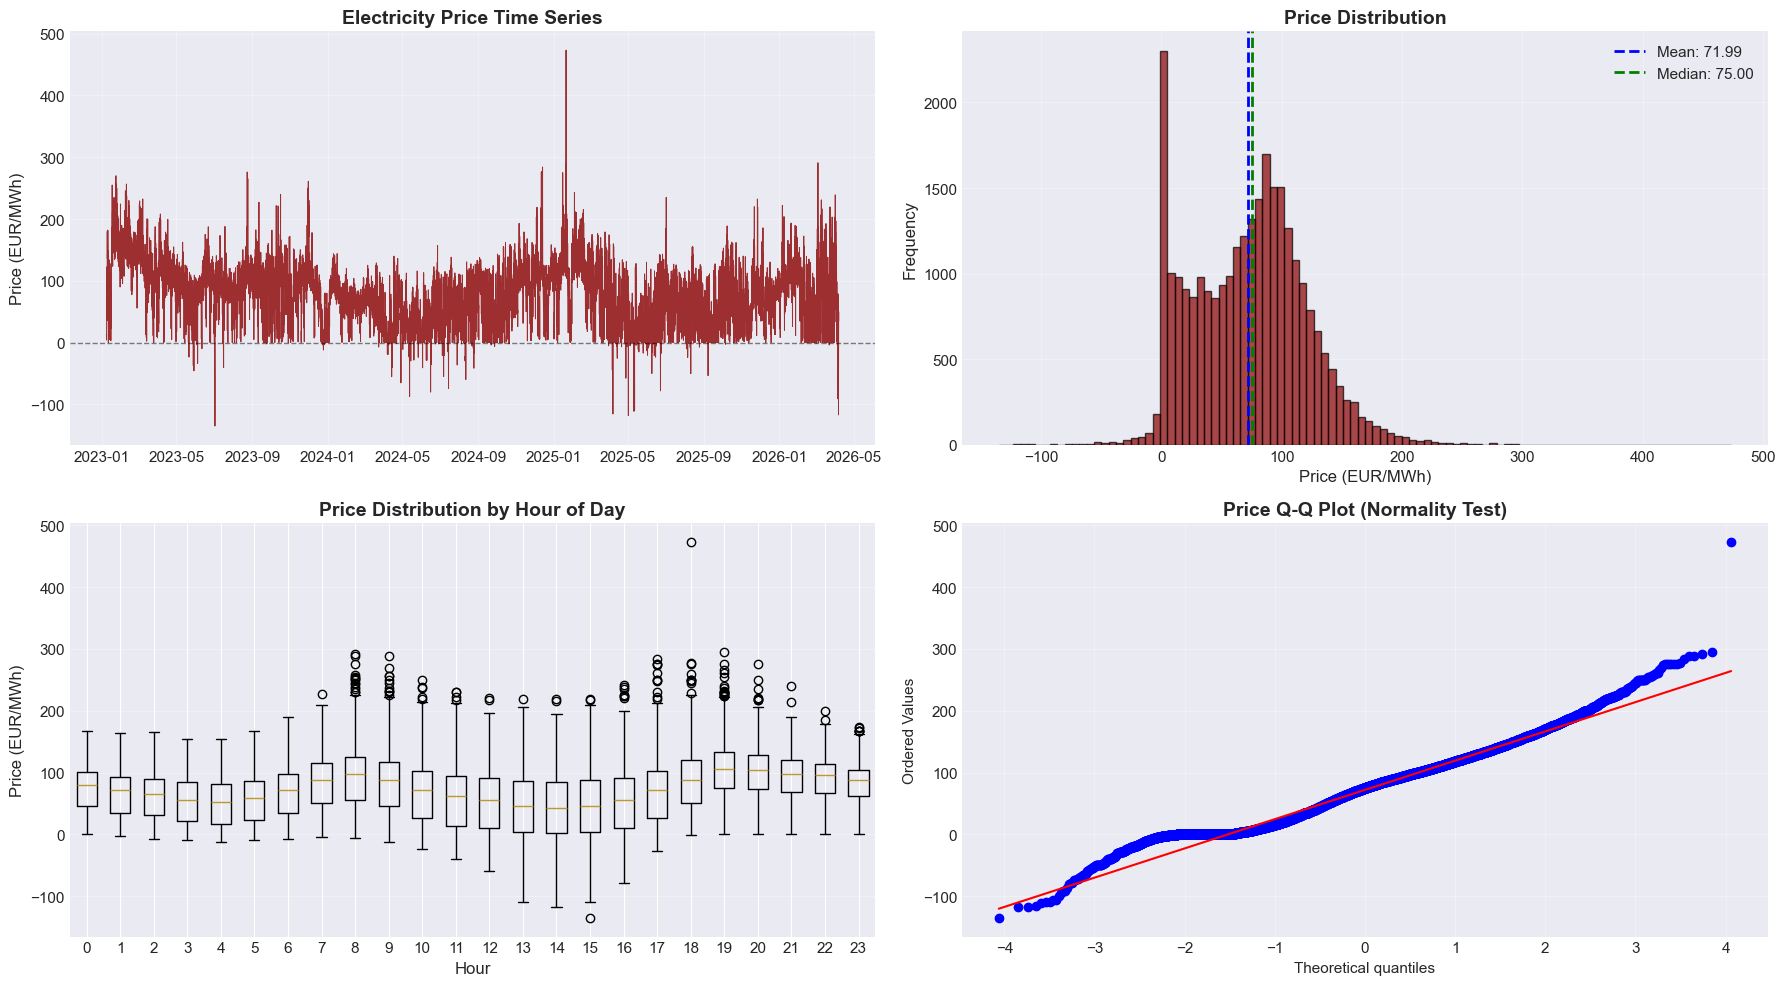


 Price Statistics:
   Mean: 71.99 EUR/MWh
   Median: 75.00 EUR/MWh
   Std Dev: 47.79 EUR/MWh
   Min: -134.94 EUR/MWh
   Max: 473.28 EUR/MWh
   Skewness: 0.256
   Kurtosis: 0.129

   Negative prices: 1086 (3.82%)


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Time series
axes[0, 0].plot(df['datetime'], df['price'], linewidth=0.7, alpha=0.8, color='darkred')
axes[0, 0].set_title('Electricity Price Time Series', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Price (EUR/MWh)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Distribution
axes[0, 1].hist(df['price'], bins=100, edgecolor='black', alpha=0.7, color='darkred')
axes[0, 1].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Price (EUR/MWh)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].axvline(df['price'].mean(), color='blue', linestyle='--', linewidth=2, label=f"Mean: {df['price'].mean():.2f}")
axes[0, 1].axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df['price'].median():.2f}")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plot by hour
hour_price = df.groupby(df['datetime'].dt.hour)['price'].apply(list)
axes[1, 0].boxplot(hour_price, positions=range(24), widths=0.6)
axes[1, 0].set_title('Price Distribution by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Hour', fontsize=12)
axes[1, 0].set_ylabel('Price (EUR/MWh)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Q-Q plot
stats.probplot(df['price'].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Price Q-Q Plot (Normality Test)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Price statistics
print("\n Price Statistics:")
print(f"   Mean: {df['price'].mean():.2f} EUR/MWh")
print(f"   Median: {df['price'].median():.2f} EUR/MWh")
print(f"   Std Dev: {df['price'].std():.2f} EUR/MWh")
print(f"   Min: {df['price'].min():.2f} EUR/MWh")
print(f"   Max: {df['price'].max():.2f} EUR/MWh")
print(f"   Skewness: {df['price'].skew():.3f}")
print(f"   Kurtosis: {df['price'].kurtosis():.3f}")
print(f"\n   Negative prices: {(df['price'] < 0).sum()} ({(df['price'] < 0).sum() / len(df) * 100:.2f}%)")

## 4. Weather Forecast Features


Weather Statistics:
       temperature_2m  wind_speed_10m  precipitation  shortwave_radiation
count        28405.00        28405.00       28405.00             28405.00
mean            12.32           11.77           0.11               136.20
std              6.97            6.32           0.46               210.53
min             -6.30            0.00           0.00                 0.00
25%              7.70            7.20           0.00                 0.00
50%             11.80           10.50           0.00                 5.00
75%             17.00           15.30           0.00               210.00
max             38.70           47.00          13.50               910.00


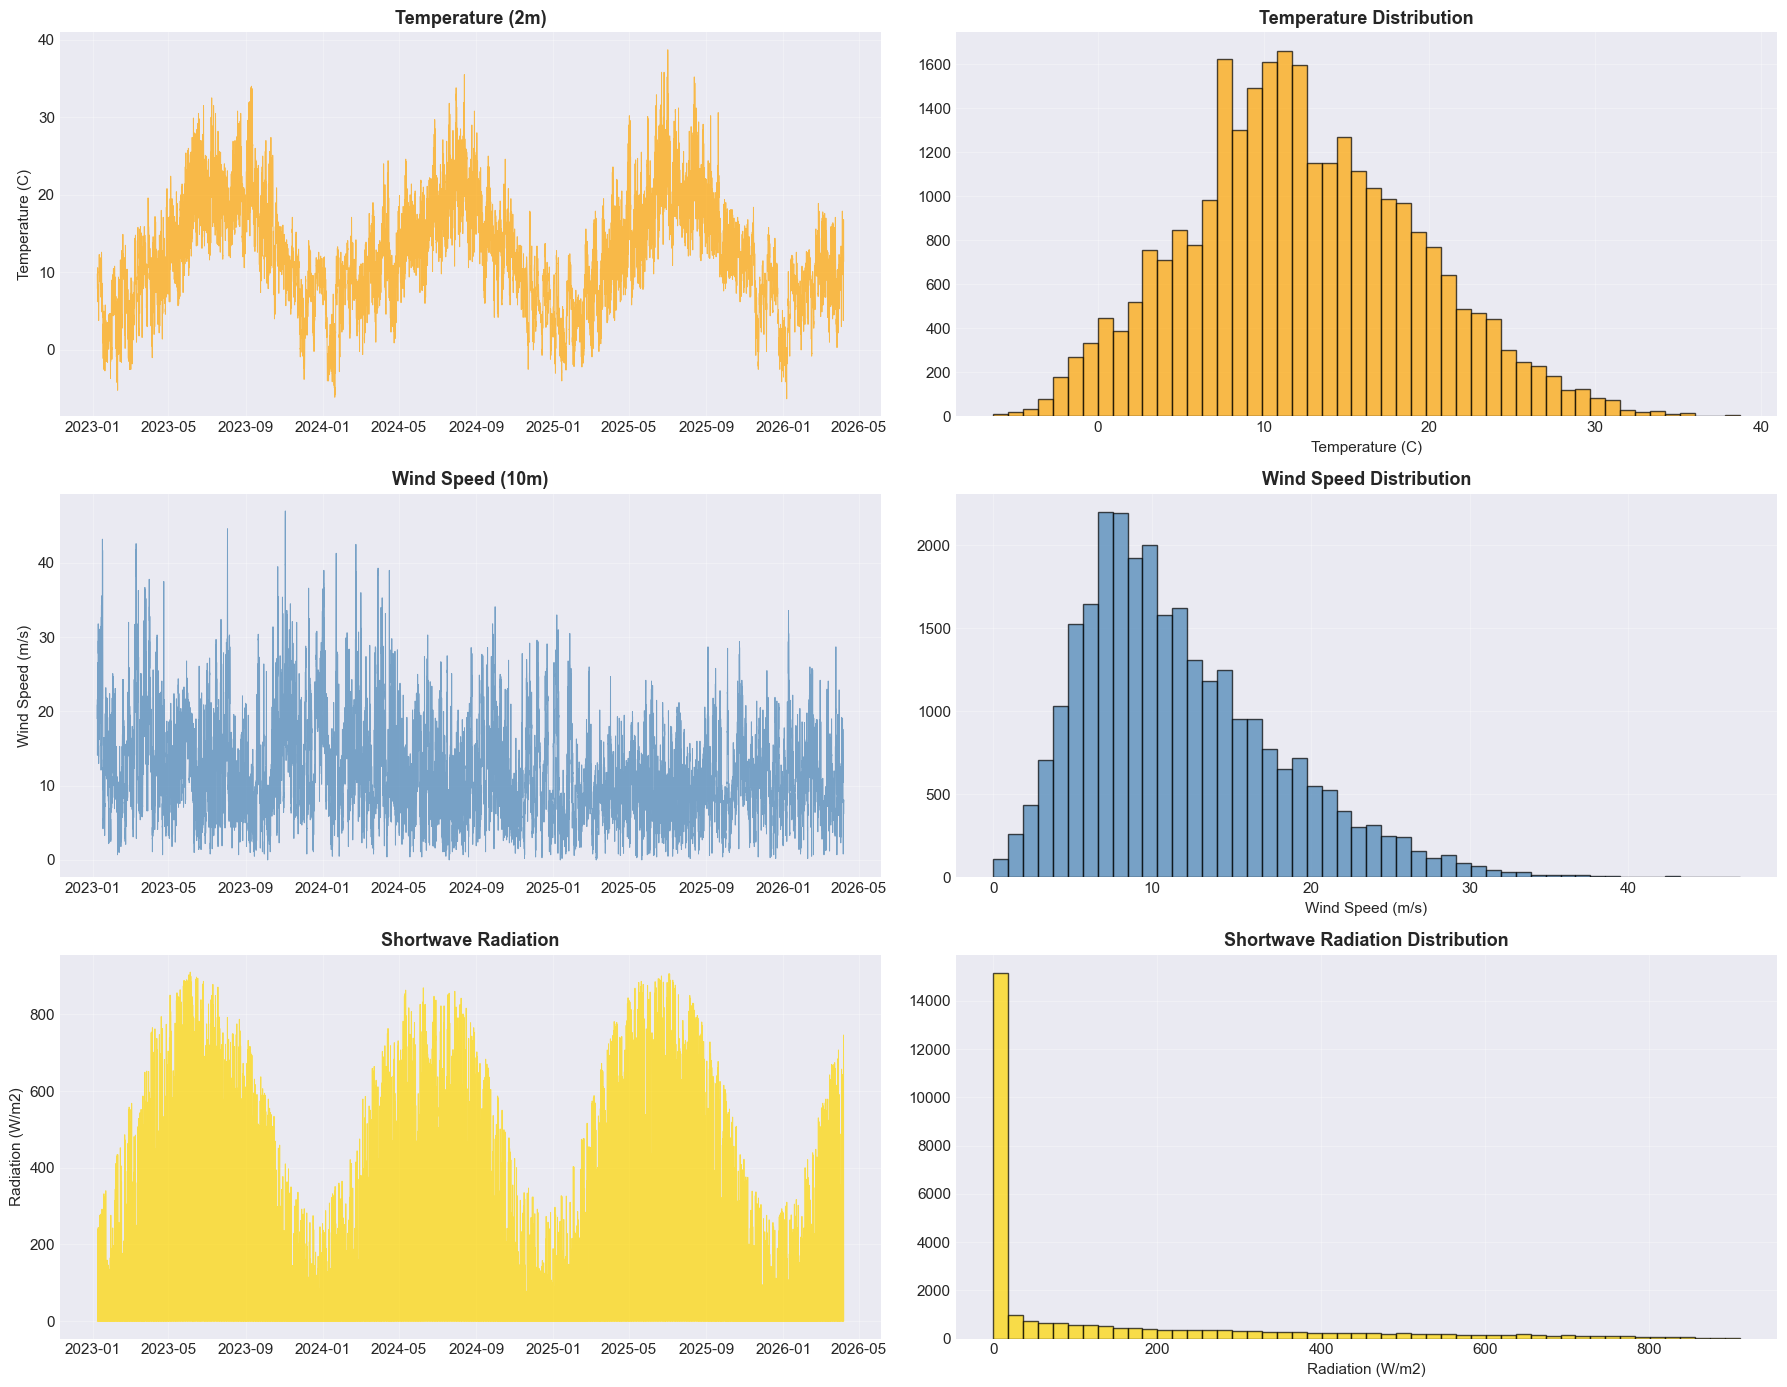

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# Temperature
axes[0, 0].plot(df['datetime'], df['temperature_2m'], linewidth=0.7, alpha=0.7, color='orange')
axes[0, 0].set_title('Temperature (2m)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Temperature (C)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df['temperature_2m'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Temperature Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Temperature (C)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Wind speed
axes[1, 0].plot(df['datetime'], df['wind_speed_10m'], linewidth=0.7, alpha=0.7, color='steelblue')
axes[1, 0].set_title('Wind Speed (10m)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Wind Speed (m/s)', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(df['wind_speed_10m'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 1].set_title('Wind Speed Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Wind Speed (m/s)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# Solar radiation
axes[2, 0].plot(df['datetime'], df['shortwave_radiation'], linewidth=0.7, alpha=0.7, color='gold')
axes[2, 0].set_title('Shortwave Radiation', fontsize=13, fontweight='bold')
axes[2, 0].set_ylabel('Radiation (W/m2)', fontsize=11)
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].hist(df['shortwave_radiation'], bins=50, edgecolor='black', alpha=0.7, color='gold')
axes[2, 1].set_title('Shortwave Radiation Distribution', fontsize=13, fontweight='bold')
axes[2, 1].set_xlabel('Radiation (W/m2)', fontsize=11)
axes[2, 1].grid(True, alpha=0.3)

print("\nWeather Statistics:")
weather_vars = ['temperature_2m', 'wind_speed_10m', 'precipitation', 'shortwave_radiation']
print(df[weather_vars].describe().round(2).to_string())

plt.tight_layout()
plt.show()

## 5. Load & Renewable Forecasts


Load & Renewable Statistics:
        load_mw  wind_production_mw  solar_production_mw  renewable_production_mw  renewable_penetration_pct
count  27518.00            28405.00             28405.00                 28405.00                   27518.00
mean   50810.01            11363.55               393.61                 11757.15                       0.24
std    10647.27             9377.91               608.43                  9446.41                       0.20
min    30143.50                0.00                 0.00                     0.00                       0.00
25%    42980.75             1528.62                 0.00                  1931.41                       0.04
50%    49171.00             9913.85                14.45                 10351.17                       0.21
75%    58001.88            22000.00               606.90                 22000.00                       0.42
max    95511.50            22000.00              2629.90                 24629.90                 

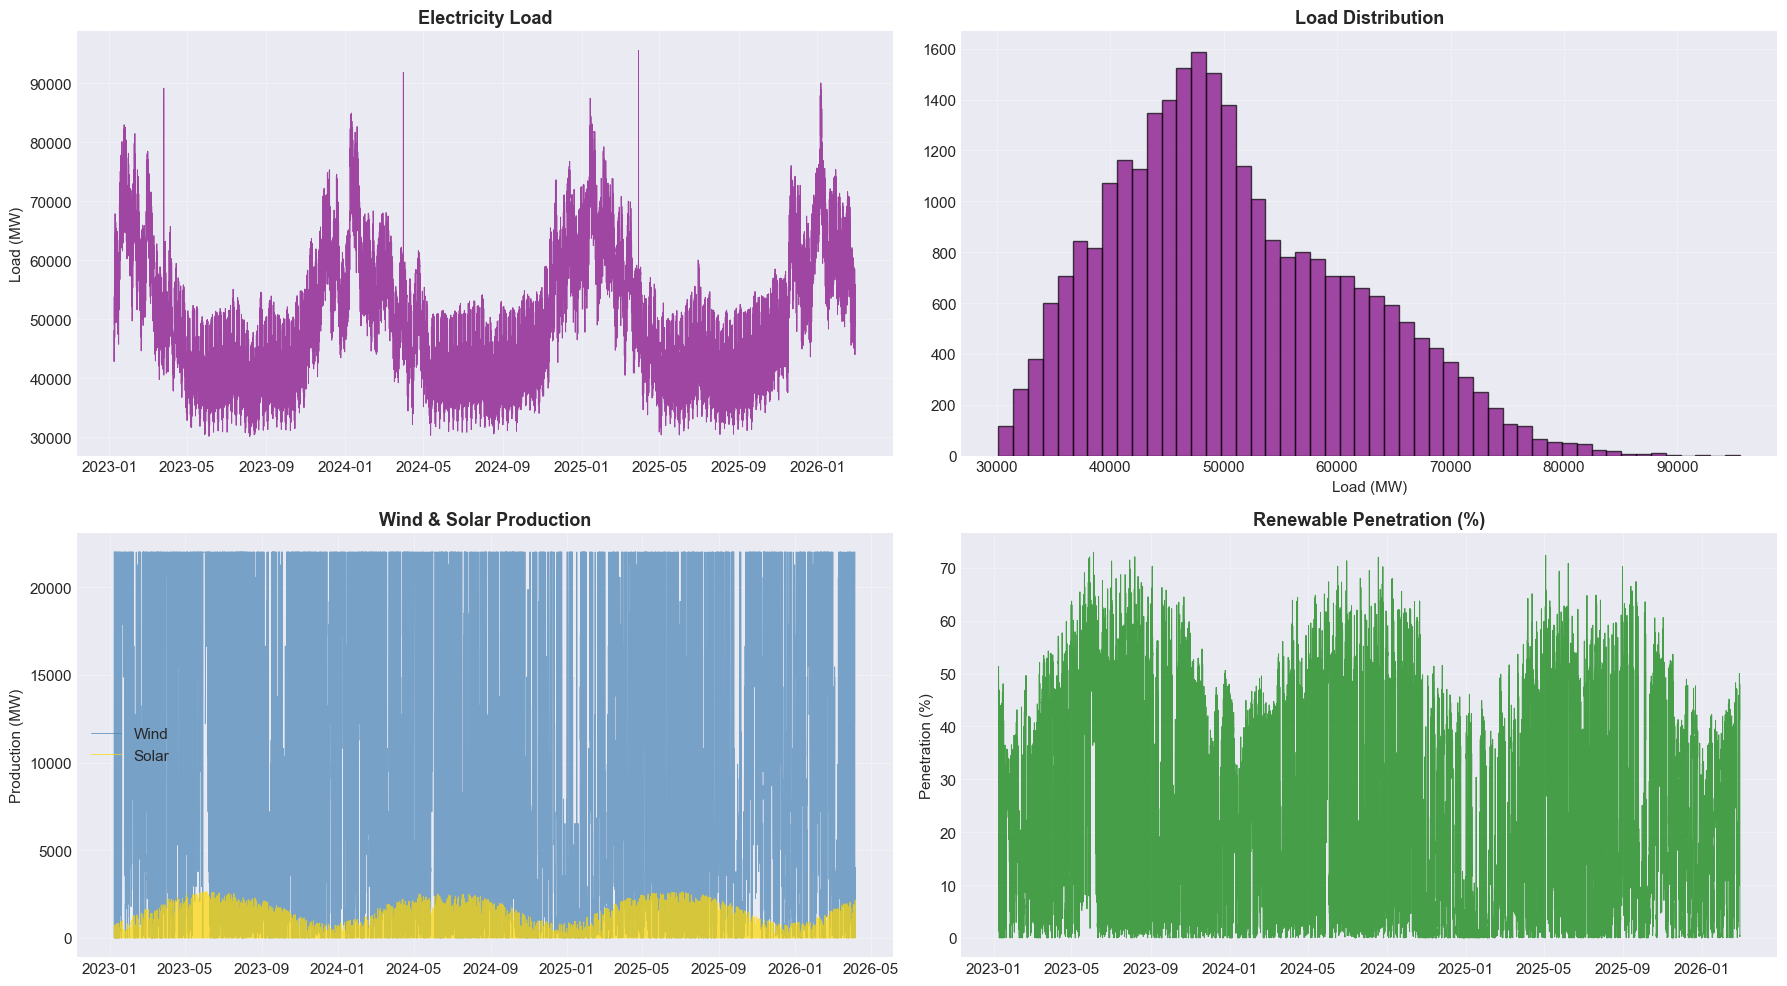

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0, 0].plot(df['datetime'], df['load_mw'], linewidth=0.7, alpha=0.7, color='purple')
axes[0, 0].set_title('Electricity Load', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Load (MW)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df['load_mw'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0, 1].set_title('Load Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Load (MW)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(df['datetime'], df['wind_production_mw'], linewidth=0.7, alpha=0.7, label='Wind', color='steelblue')
axes[1, 0].plot(df['datetime'], df['solar_production_mw'], linewidth=0.7, alpha=0.7, label='Solar', color='gold')
axes[1, 0].set_title('Wind & Solar Production', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Production (MW)', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(df['datetime'], df['renewable_penetration_pct'] * 100, linewidth=0.7, alpha=0.7, color='green')
axes[1, 1].set_title('Renewable Penetration (%)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Penetration (%)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

print("\nLoad & Renewable Statistics:")
print(df[['load_mw', 'wind_production_mw', 'solar_production_mw', 'renewable_production_mw', 'renewable_penetration_pct']].describe().round(2).to_string())

plt.tight_layout()
plt.show()

## 6. Net Load Analysis


Net Load Statistics:
       net_load_mw  renewable_penetration_pct
count     27518.00                   27518.00
mean      38968.20                       0.24
std       13921.81                       0.20
min        8143.50                       0.00
25%       28348.65                       0.04
50%       38255.91                       0.21
75%       47839.29                       0.42
max       95190.16                       0.73


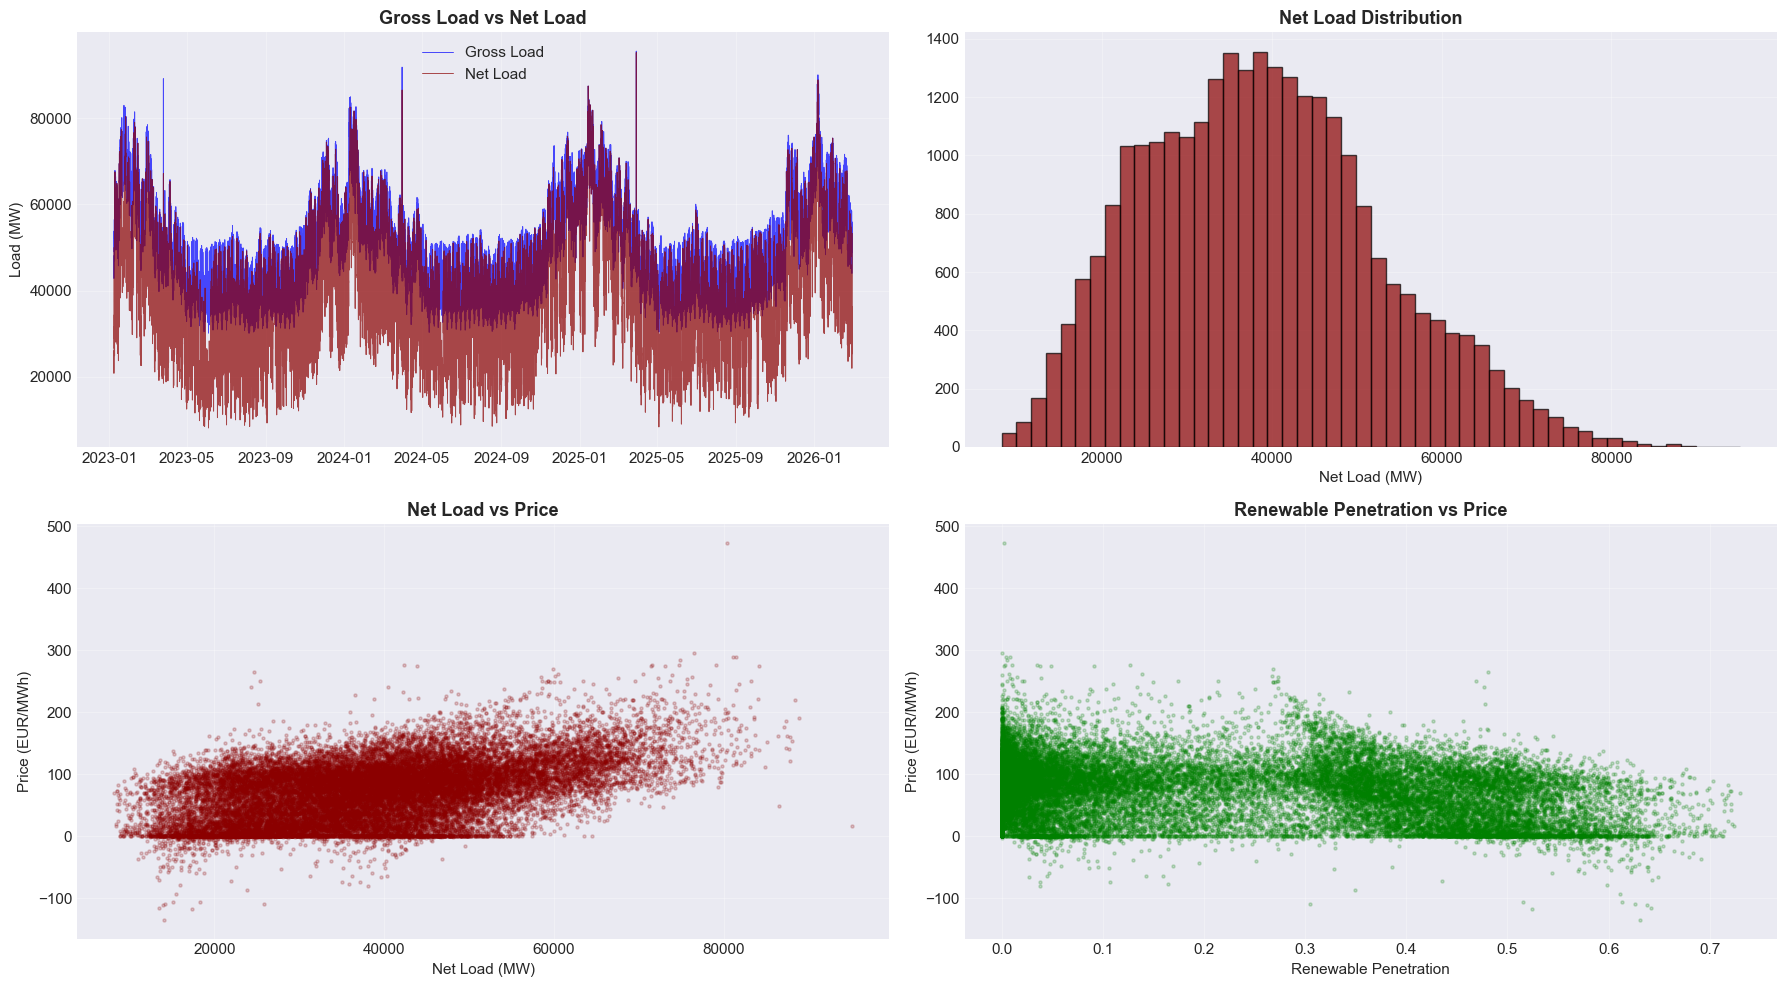

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0, 0].plot(df['datetime'], df['load_mw'], linewidth=0.7, alpha=0.7, label='Gross Load', color='blue')
axes[0, 0].plot(df['datetime'], df['net_load_mw'], linewidth=0.7, alpha=0.7, label='Net Load', color='darkred')
axes[0, 0].set_title('Gross Load vs Net Load', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Load (MW)', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df['net_load_mw'], bins=50, edgecolor='black', alpha=0.7, color='darkred')
axes[0, 1].set_title('Net Load Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Net Load (MW)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(df['net_load_mw'], df['price'], alpha=0.2, s=5, color='darkred')
axes[1, 0].set_title('Net Load vs Price', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Net Load (MW)', fontsize=11)
axes[1, 0].set_ylabel('Price (EUR/MWh)', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(df['renewable_penetration_pct'], df['price'], alpha=0.2, s=5, color='green')
axes[1, 1].set_title('Renewable Penetration vs Price', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Renewable Penetration', fontsize=11)
axes[1, 1].set_ylabel('Price (EUR/MWh)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

print("\nNet Load Statistics:")
print(df[['net_load_mw', 'renewable_penetration_pct']].describe().round(2).to_string())

plt.tight_layout()
plt.show()

## 7. Historical Features (Lags & Rolling Stats)

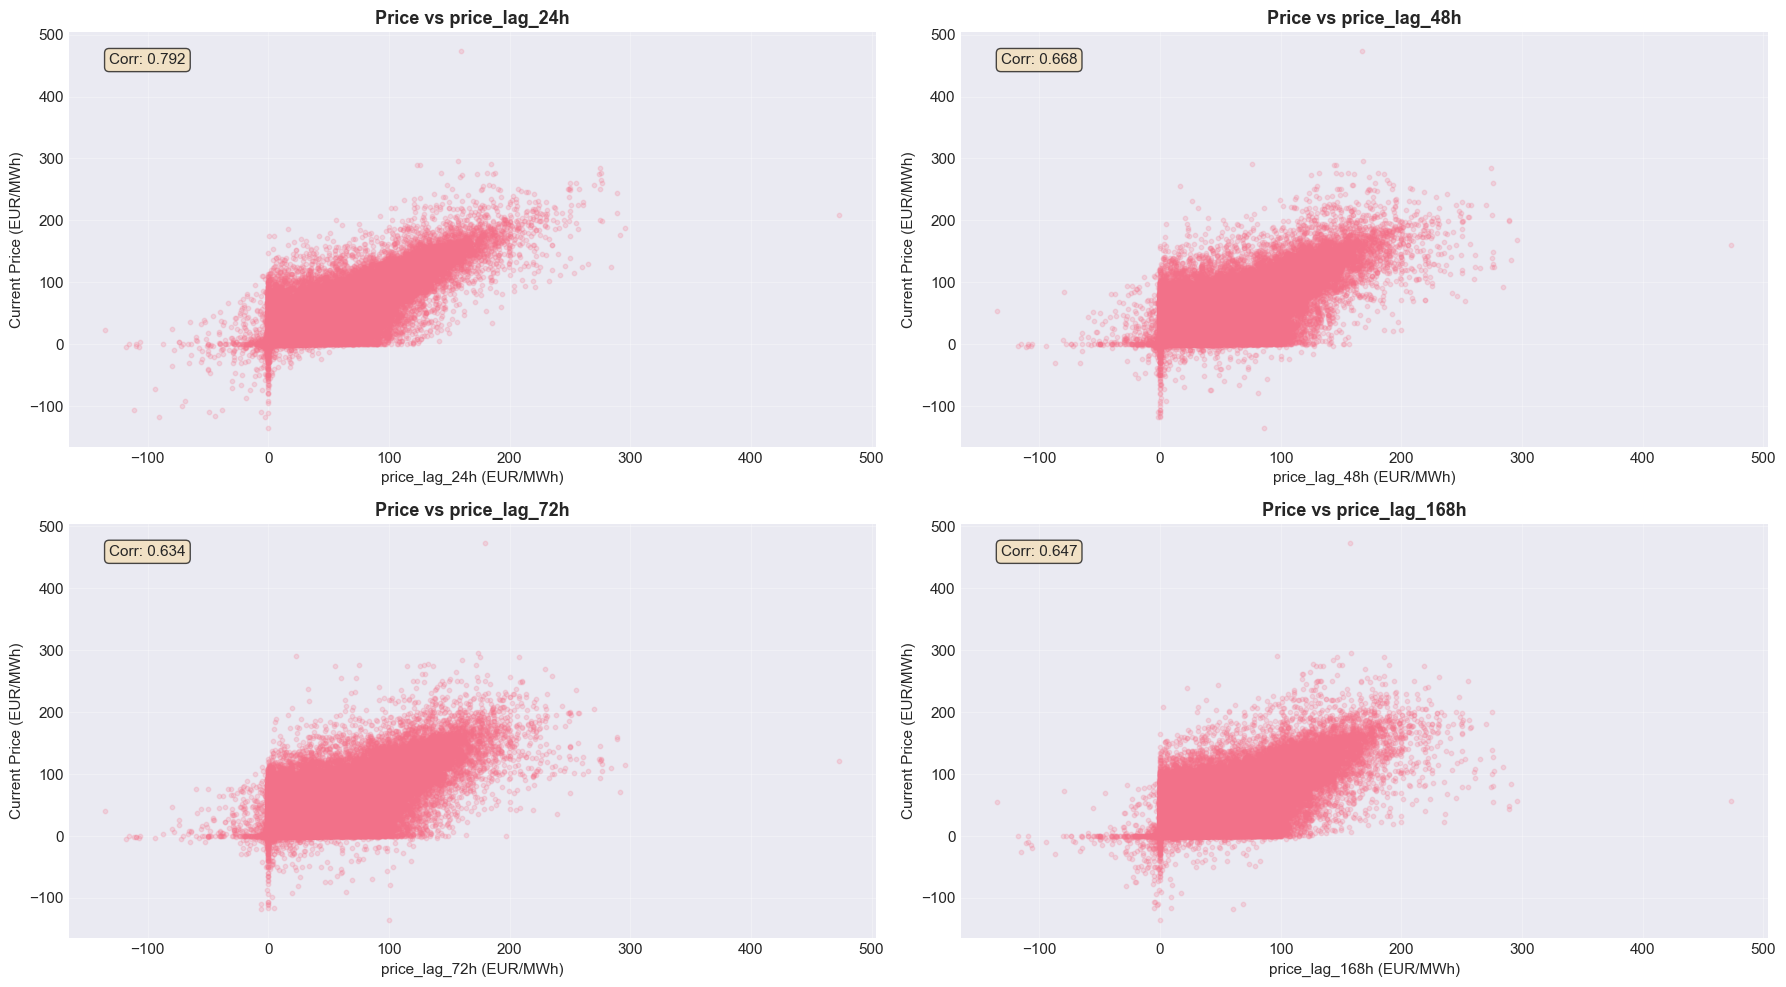


 Lag Feature Correlations with Price:
   price_lag_24h: 0.7922
   price_lag_48h: 0.6677
   price_lag_72h: 0.6338
   price_lag_168h: 0.6468


In [11]:
# Plot lag features
lag_cols = ['price_lag_24h', 'price_lag_48h', 'price_lag_72h', 'price_lag_168h']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for i, lag_col in enumerate(lag_cols):
    ax = axes[i // 2, i % 2]
    ax.scatter(df[lag_col], df['price'], alpha=0.2, s=10)
    ax.set_title(f'Price vs {lag_col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{lag_col} (EUR/MWh)', fontsize=11)
    ax.set_ylabel('Current Price (EUR/MWh)', fontsize=11)
    
    # Add correlation
    corr = df[[lag_col, 'price']].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'Corr: {corr:.3f}', transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Lag Feature Correlations with Price:")
for lag_col in lag_cols:
    corr = df[[lag_col, 'price']].corr().iloc[0, 1]
    print(f"   {lag_col}: {corr:.4f}")

## 8. Correlation Analysis

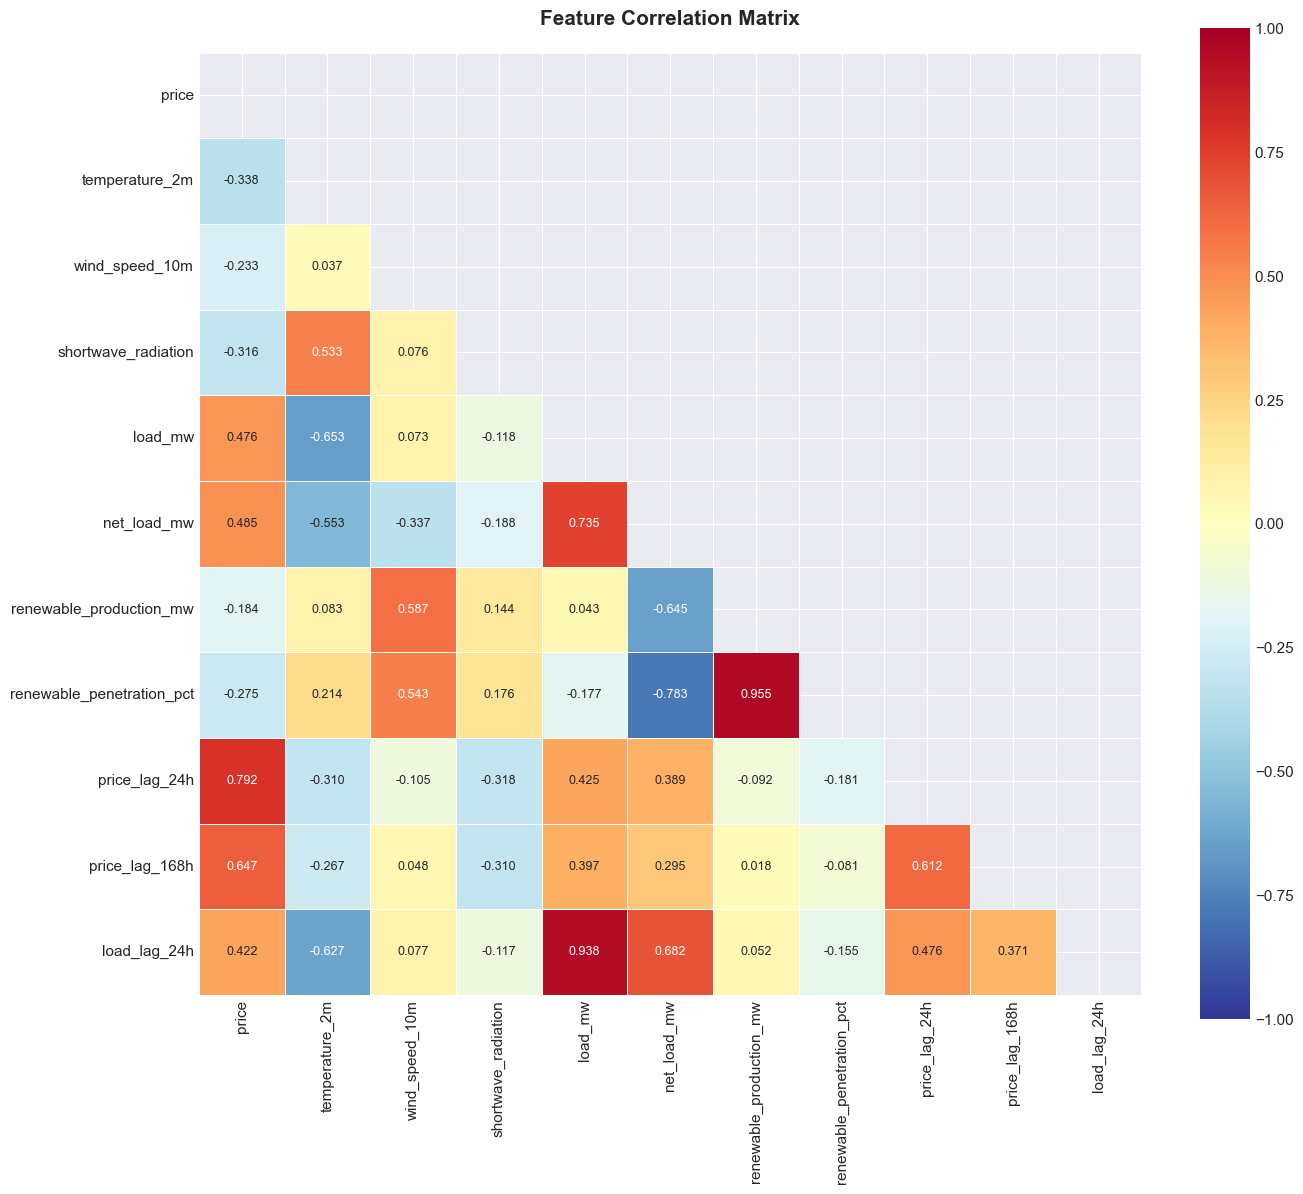


Top 15 Features Correlated with Price:

price_lag_24h                0.792190
price_lag_168h               0.646776
net_load_mw                  0.484819
load_mw                      0.475672
load_lag_24h                 0.421962
temperature_2m               0.338134
shortwave_radiation          0.316271
renewable_penetration_pct    0.275091
wind_speed_10m               0.232970
renewable_production_mw      0.183816


In [12]:
# Select key features for correlation matrix
key_features = [
    'price',
    'temperature_2m',
    'wind_speed_10m',
    'shortwave_radiation',
    'load_mw',
    'net_load_mw',
    'renewable_production_mw',
    'renewable_penetration_pct',
    'price_lag_24h',
    'price_lag_168h',
    'load_lag_24h',
]

# Compute correlation matrix
corr_matrix = df[key_features].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdYlBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print top correlations with price
price_corr = corr_matrix['price'].drop('price').abs().sort_values(ascending=False)
print("\nTop 15 Features Correlated with Price:\n")
print(price_corr.head(15).to_string())

## 9. Temporal Patterns

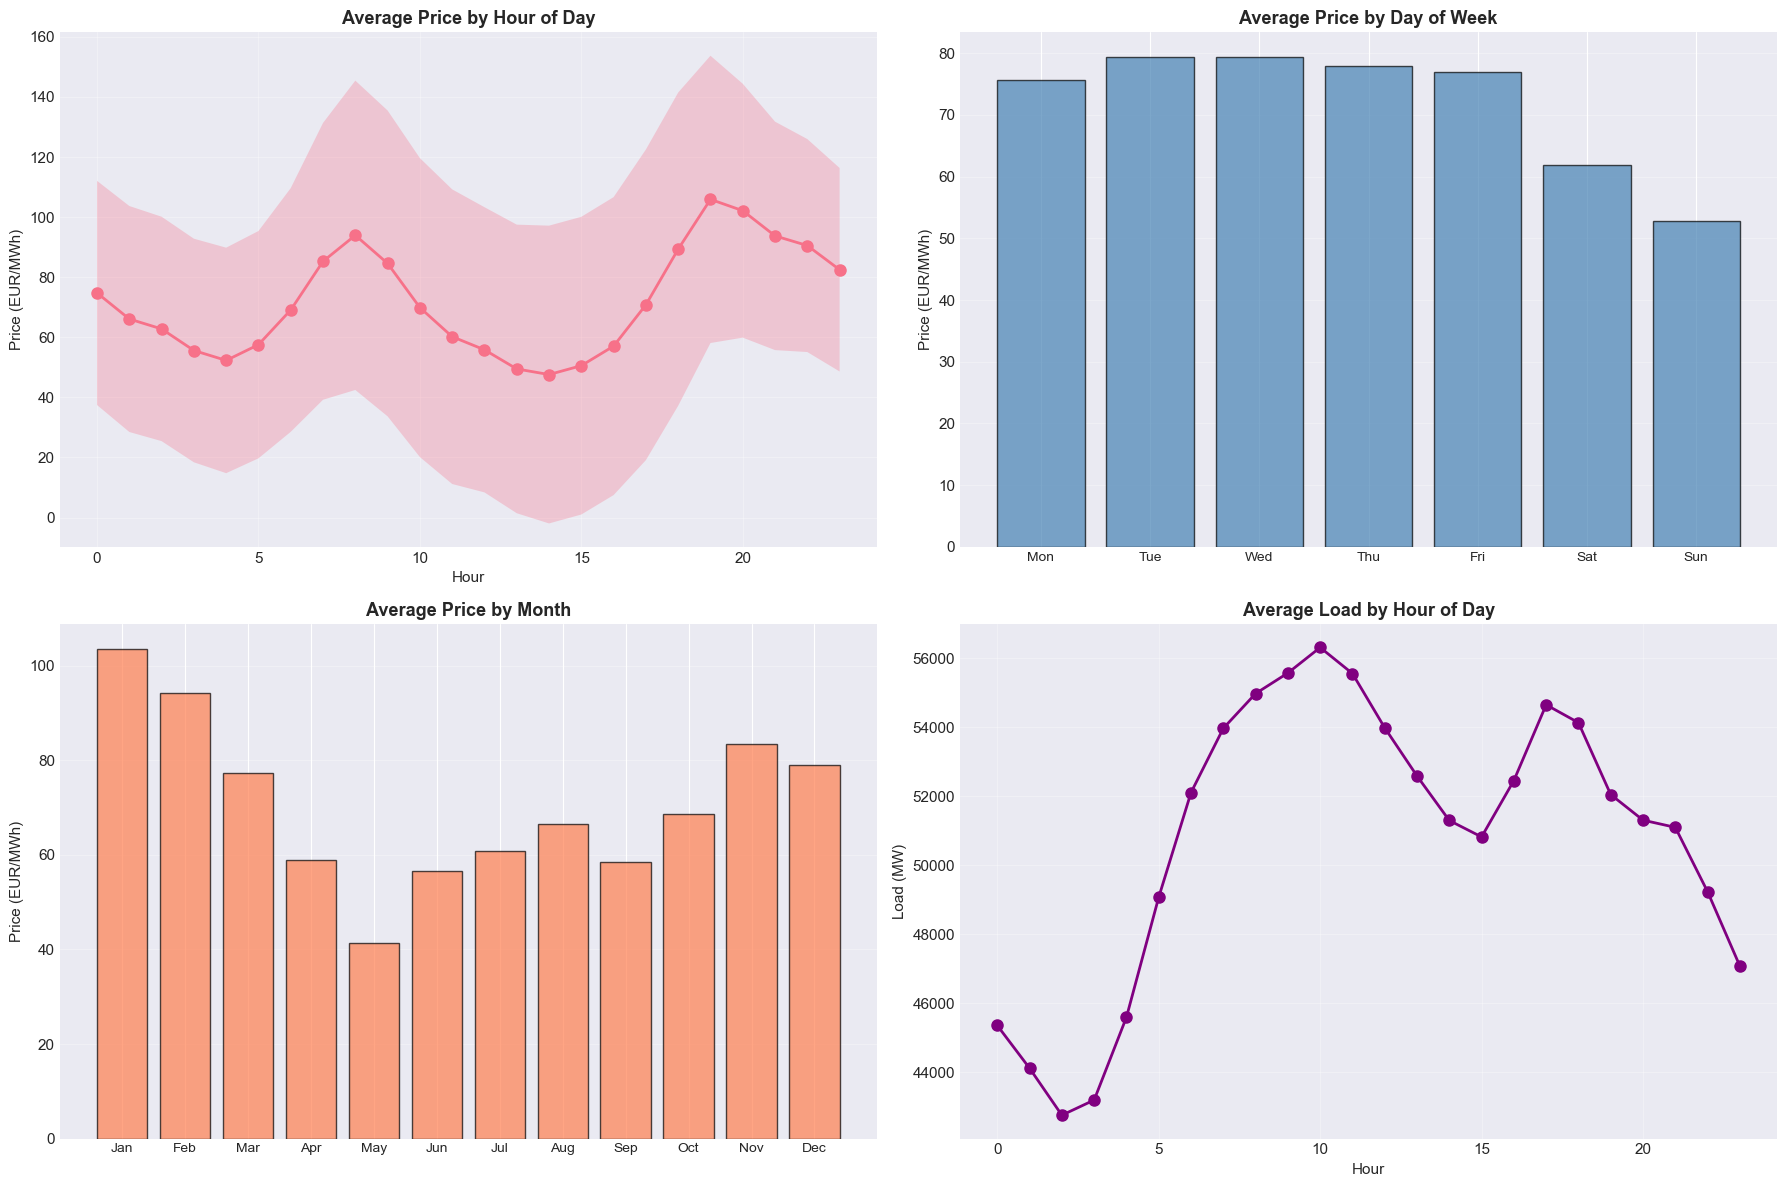

In [13]:
# Add temporal features for analysis
df['hour_of_day'] = df['datetime'].dt.hour
df['day_of_week_name'] = df['datetime'].dt.day_name()
df['month_name'] = df['datetime'].dt.month_name()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Price by hour
hourly_price = df.groupby('hour_of_day')['price'].agg(['mean', 'std'])
axes[0, 0].plot(hourly_price.index, hourly_price['mean'], marker='o', linewidth=2, markersize=8)
axes[0, 0].fill_between(hourly_price.index,
                        hourly_price['mean'] - hourly_price['std'],
                        hourly_price['mean'] + hourly_price['std'],
                        alpha=0.3, label='Mean +/- Std')
axes[0, 0].set_title('Average Price by Hour of Day', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Hour', fontsize=11)
axes[0, 0].set_ylabel('Price (EUR/MWh)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Price by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_price = df.groupby('day_of_week_name')['price'].mean().reindex(day_order)
axes[0, 1].bar(range(7), daily_price.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels([d[:3] for d in day_order], fontsize=10)
axes[0, 1].set_title('Average Price by Day of Week', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Price (EUR/MWh)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Price by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_price = df.groupby('month_name')['price'].mean().reindex(month_order)
axes[1, 0].bar(range(12), monthly_price.values, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xticks(range(12))
axes[1, 0].set_xticklabels([m[:3] for m in month_order], fontsize=10)
axes[1, 0].set_title('Average Price by Month', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Price (EUR/MWh)', fontsize=11)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Load by hour
hourly_load = df.groupby('hour_of_day')['load_mw'].mean()
axes[1, 1].plot(hourly_load.index, hourly_load.values, marker='o', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_title('Average Load by Hour of Day', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Hour', fontsize=11)
axes[1, 1].set_ylabel('Load (MW)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Feature Importance Preview (Quick RF)

Training quick Random Forest for feature importance...


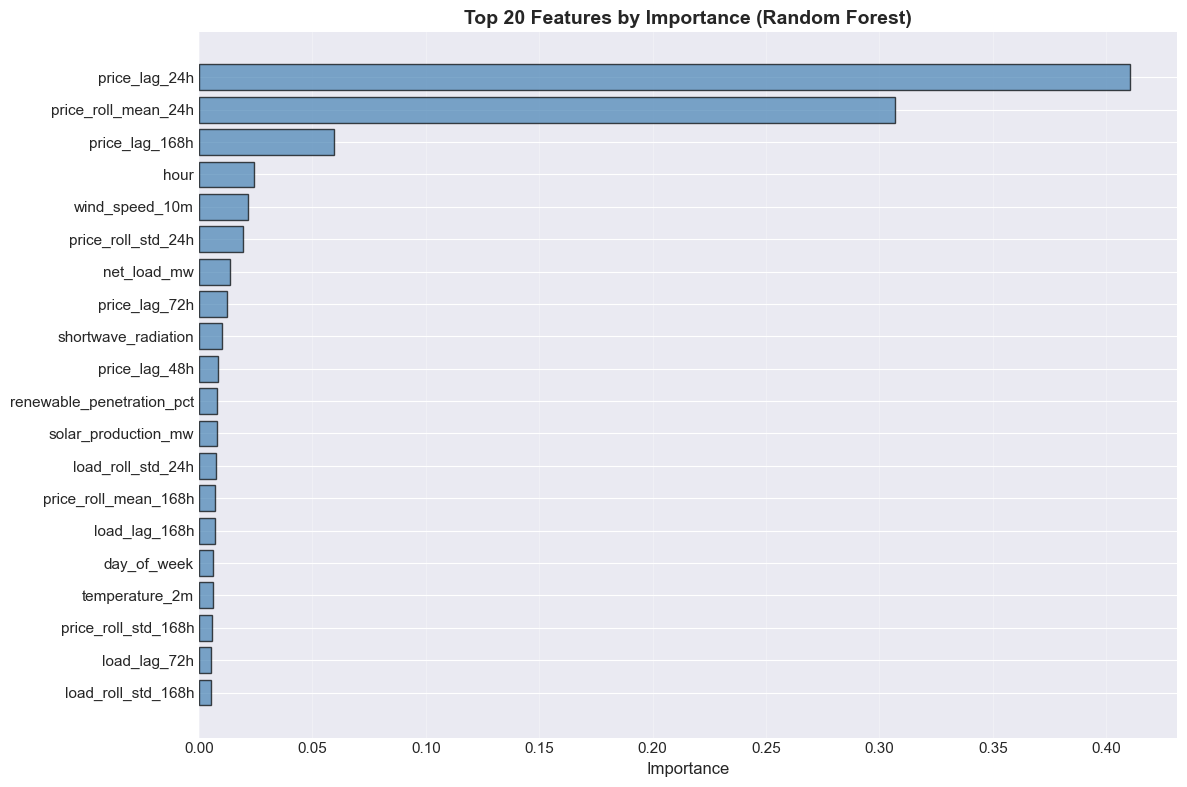


 Top 20 Features:

                  feature  importance
            price_lag_24h    0.410643
      price_roll_mean_24h    0.306711
           price_lag_168h    0.059535
                     hour    0.024455
           wind_speed_10m    0.021780
       price_roll_std_24h    0.019440
              net_load_mw    0.013667
            price_lag_72h    0.012241
      shortwave_radiation    0.010294
            price_lag_48h    0.008412
renewable_penetration_pct    0.007898
      solar_production_mw    0.007863
        load_roll_std_24h    0.007569
     price_roll_mean_168h    0.007007
            load_lag_168h    0.006925
              day_of_week    0.006375
           temperature_2m    0.006222
      price_roll_std_168h    0.005940
             load_lag_72h    0.005269
       load_roll_std_168h    0.005214


In [14]:
from sklearn.ensemble import RandomForestRegressor

# Quick feature importance with small RF
print("Training quick Random Forest for feature importance...")

# Sample data for speed
sample_size = min(5000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

X_sample = df_sample[feature_cols]
y_sample = df_sample['price']

# Train small RF
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

# Get feature importances
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 20
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'].values, color='steelblue', alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 20 Features by Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n Top 20 Features:\n")
print(importance_df.head(20).to_string(index=False))

## 11. Data Quality Checks

In [15]:
print("Data Quality Report\n")
print("="*60)

# Check for infinite values
inf_counts = np.isinf(df[feature_cols + ['price']]).sum()
if inf_counts.sum() > 0:
    print("Infinite values found:")
    print(inf_counts[inf_counts > 0])
else:
    print("No infinite values")

# Check for duplicates
duplicates = df.duplicated(subset=['datetime']).sum()
if duplicates > 0:
    print(f"\n{duplicates} duplicate timestamps found")
else:
    print("\nNo duplicate timestamps")

# Check time gaps
time_diffs = df['datetime'].diff()
expected_diff = pd.Timedelta('1 hour')
gaps = time_diffs[time_diffs != expected_diff]
if len(gaps) > 1:  # First row will be NaT
    print(f"\n{len(gaps)-1} time gaps found (not hourly)")
    print("   First few gaps:")
    print(gaps.head())
else:
    print("\nConsistent hourly timestamps")

# Check value ranges
print("\nValue Range Checks:")
temp_ok = df['temperature_2m'].min() > -20 and df['temperature_2m'].max() < 50
wind_ok = df['wind_speed_10m'].min() >= 0
solar_ok = df['shortwave_radiation'].min() >= 0 and df['shortwave_radiation'].max() < 1500
load_ok = df['load_mw'].dropna().min() > 10000
renew_ok = df['renewable_production_mw'].min() >= 0
print(f"   Temperature: [{df['temperature_2m'].min():.1f}, {df['temperature_2m'].max():.1f}] C - {'OK' if temp_ok else 'CHECK'}")
print(f"   Wind speed: [{df['wind_speed_10m'].min():.1f}, {df['wind_speed_10m'].max():.1f}] m/s - {'OK' if wind_ok else 'CHECK'}")
print(f"   Solar radiation: [{df['shortwave_radiation'].min():.0f}, {df['shortwave_radiation'].max():.0f}] W/m2 - {'OK' if solar_ok else 'CHECK'}")
print(f"   Load: [{df['load_mw'].min():.0f}, {df['load_mw'].max():.0f}] MW - {'OK' if load_ok else 'CHECK (may have NaN weeks)'}")
print(f"   Renewable production: [{df['renewable_production_mw'].min():.0f}, {df['renewable_production_mw'].max():.0f}] MW - {'OK' if renew_ok else 'CHECK'}")

print("\nData quality checks complete.")

Data Quality Report

No infinite values

No duplicate timestamps

35 time gaps found (not hourly)
   First few gaps:
0                  NaT
1850   0 days 02:00:00
1873   0 days 02:00:00
1896   0 days 02:00:00
1919   0 days 02:00:00
Name: datetime, dtype: timedelta64[ns]

Value Range Checks:
   Temperature: [-6.3, 38.7] C - OK
   Wind speed: [0.0, 47.0] m/s - OK
   Solar radiation: [0, 910] W/m2 - OK
   Load: [30144, 95512] MW - OK
   Renewable production: [0, 24630] MW - OK

Data quality checks complete.


## 12. Summary & Key Insights

In [16]:
print("DATASET SUMMARY")
print("="*60)

print("\nDataset Information:")
print(f"   Period: {df['datetime'].min().date()} to {df['datetime'].max().date()}")
print(f"   Samples: {len(df):,} hourly observations")
print(f"   Features: {len(feature_cols)}")
print(f"   Target: Electricity price (EUR/MWh)")

print("\nTarget Variable (Price):")
print(f"   Range: [{df['price'].min():.2f}, {df['price'].max():.2f}] EUR/MWh")
print(f"   Mean: {df['price'].mean():.2f} EUR/MWh")
print(f"   Std: {df['price'].std():.2f} EUR/MWh")
print(f"   Negative prices: {(df['price'] < 0).sum()} ({(df['price'] < 0).sum()/len(df)*100:.1f}%)")

print("\nWeather Features:")
print(f"   Temperature: {df['temperature_2m'].mean():.1f} C +/- {df['temperature_2m'].std():.1f} C")
print(f"   Wind speed (10m): {df['wind_speed_10m'].mean():.1f} m/s +/- {df['wind_speed_10m'].std():.1f} m/s")
print(f"   Solar radiation: {df['shortwave_radiation'].mean():.0f} W/m2 +/- {df['shortwave_radiation'].std():.0f} W/m2")

print("\nLoad & Renewables:")
load_valid = df['load_mw'].dropna()
print(f"   Load: {load_valid.mean():.0f} MW +/- {load_valid.std():.0f} MW (non-null: {len(load_valid):,})")
print(f"   Wind production: {df['wind_production_mw'].mean():.0f} MW")
print(f"   Solar production: {df['solar_production_mw'].mean():.0f} MW")
print(f"   Renewable penetration: {df['renewable_penetration_pct'].mean()*100:.1f}%")
print(f"   Net load: {df['net_load_mw'].mean():.0f} MW")

print("\nKey Correlations with Price:")
key_corr_cols = ['temperature_2m', 'wind_speed_10m', 'shortwave_radiation',
                 'net_load_mw', 'price_lag_24h', 'price_lag_168h']
for col in key_corr_cols:
    print(f"   {col}: {df['price'].corr(df[col]):.4f}")

print("\nData Quality:")
print(f"   Missing values: {df[feature_cols + ['price']].isnull().sum().sum()}")
print(f"   Duplicate timestamps: {df.duplicated(subset=['datetime']).sum()}")
print(f"   Infinite values: {np.isinf(df[feature_cols + ['price']]).sum().sum()}")

DATASET SUMMARY

Dataset Information:
   Period: 2023-01-08 to 2026-04-06
   Samples: 28,405 hourly observations
   Features: 44
   Target: Electricity price (EUR/MWh)

Target Variable (Price):
   Range: [-134.94, 473.28] EUR/MWh
   Mean: 71.99 EUR/MWh
   Std: 47.79 EUR/MWh
   Negative prices: 1086 (3.8%)

Weather Features:
   Temperature: 12.3 C +/- 7.0 C
   Wind speed (10m): 11.8 m/s +/- 6.3 m/s
   Solar radiation: 136 W/m2 +/- 211 W/m2

Load & Renewables:
   Load: 50810 MW +/- 10647 MW (non-null: 27,518)
   Wind production: 11364 MW
   Solar production: 394 MW
   Renewable penetration: 24.0%
   Net load: 38968 MW

Key Correlations with Price:
   temperature_2m: -0.3381
   wind_speed_10m: -0.2330
   shortwave_radiation: -0.3163
   net_load_mw: 0.4848
   price_lag_24h: 0.7922
   price_lag_168h: 0.6468

Data Quality:
   Missing values: 8216
   Duplicate timestamps: 0
   Infinite values: 0
